# Image Emotion Detection using ResNet18

## Imports

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


## Paths & Device

In [2]:
ROOT_DIR = r"C:\Users\USER\PycharmProjects\DSGP15_Project\ml-models\dataset\Dataset"

train_dir = os.path.join(ROOT_DIR, "Images", "Emotion", "train")
test_dir  = os.path.join(ROOT_DIR, "Images", "Emotion", "test")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Image Transformations

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


## Dataset & DataLoader

In [4]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)


Classes: ['Happiness', 'Sadness']


## Load ResNet18

In [5]:
model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Fine-tune last 2 blocks + fc
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model = model.to(device)


C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Loss Function & Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0005
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


## Training Loop

In [7]:
EPOCHS = 15
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    scheduler.step()  # update learning rate

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss:.4f}")


Epoch [1/15] - Loss: 0.6233
Epoch [2/15] - Loss: 0.5428
Epoch [3/15] - Loss: 0.5157
Epoch [4/15] - Loss: 0.5006
Epoch [5/15] - Loss: 0.4789
Epoch [6/15] - Loss: 0.4347
Epoch [7/15] - Loss: 0.4095
Epoch [8/15] - Loss: 0.3953
Epoch [9/15] - Loss: 0.3712
Epoch [10/15] - Loss: 0.3498
Epoch [11/15] - Loss: 0.2807
Epoch [12/15] - Loss: 0.2542
Epoch [13/15] - Loss: 0.2287
Epoch [14/15] - Loss: 0.2083
Epoch [15/15] - Loss: 0.2041


## Training Loss Plot

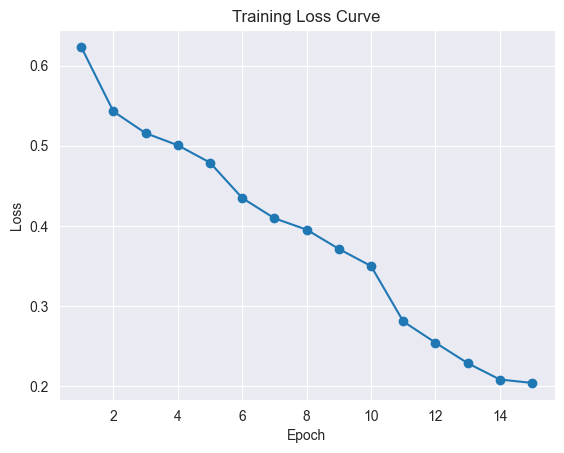

In [14]:
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


## Evaluation Function

In [15]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


## Test Evaluation

In [16]:
y_true, y_pred, y_prob = evaluate_model(model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


Test Accuracy: 0.72


## Confusion Matrix

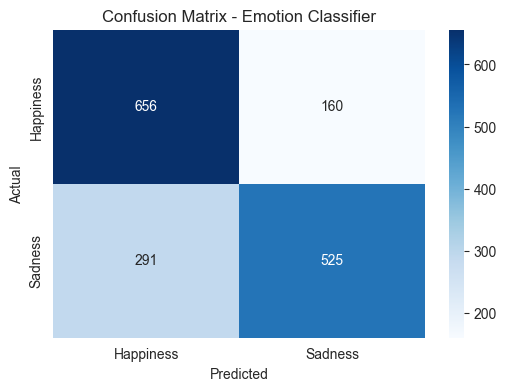

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Emotion Classifier")
plt.show()


## Classification Report

In [18]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


Classification Report:

              precision    recall  f1-score   support

   Happiness       0.69      0.80      0.74       816
     Sadness       0.77      0.64      0.70       816

    accuracy                           0.72      1632
   macro avg       0.73      0.72      0.72      1632
weighted avg       0.73      0.72      0.72      1632



## ROC Curve & AUC

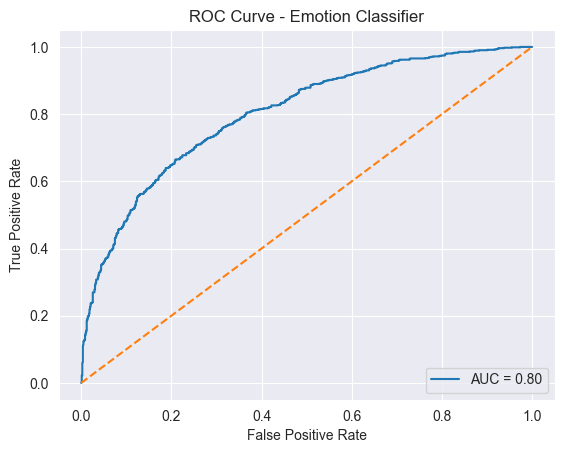

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Emotion Classifier")
plt.legend(loc="lower right")
plt.show()


## Save Model

In [20]:
torch.save(model.state_dict(), "resnet18_emotion_model_optimized.pth")
print("Model saved successfully")


Model saved successfully
